In [28]:
import numpy as np
import matplotlib.pyplot as plt
import os
from Tools.data_utils import SimulationData, lorenz_stochastic

In [29]:
# Parametri simulazione
n_steps = 10000
dt = 0.01
alpha = 9
beta = 5

# Parametri embedding
tau = 15
embedding_dim = 20

# Crea una nuova istanza
simulation = SimulationData(n_steps, dt, alpha, beta, tau, embedding_dim)

# Esegui la simulazione
simulation.run_simulation(lorenz_stochastic)

# Genera le osservabili
simulation.generate_observables()

#TO DO: Opzione per normalizare o meno i dati
# Normalizza i dati
simulation.normalize_data()

# Crea gli embedding delle osservabili
simulation.create_embeddings() # MODIFICA QUESTA PER NORMALIZZARE I DATI o meno


print("y1 shape: ", simulation.y1.shape)
print("y2 shape: ", simulation.y2.shape)
print("y1_embedding shape: ", simulation.y1_embedding.shape)
print("y2_embedding_1 shape: ", simulation.y2_embedding_1.shape)
print("y2_embedding_2 shape: ", simulation.y2_embedding_2.shape)

y1 shape:  (10000,)
y2 shape:  (10000, 2)
y1_embedding shape:  (9715, 20)
y2_embedding_1 shape:  (9715, 20)
y2_embedding_2 shape:  (9715, 20)


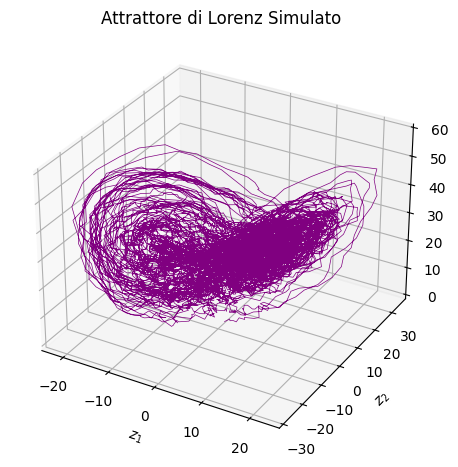

In [30]:
# Grafico delle traiettorie 
fig = plt.figure(figsize=(12, 6))
# Primo subplot
ax = fig.add_subplot(121, projection="3d")
ax.plot(simulation.trajectory[:, 0], simulation.trajectory[:, 1], simulation.trajectory[:, 2], color='purple', lw=0.5)
ax.set_title("Attrattore di Lorenz Simulato")
ax.set_xlabel(f"$z_1$")
ax.set_ylabel(f"$z_2$")
ax.set_zlabel(f"$z_3$")
plt.show()


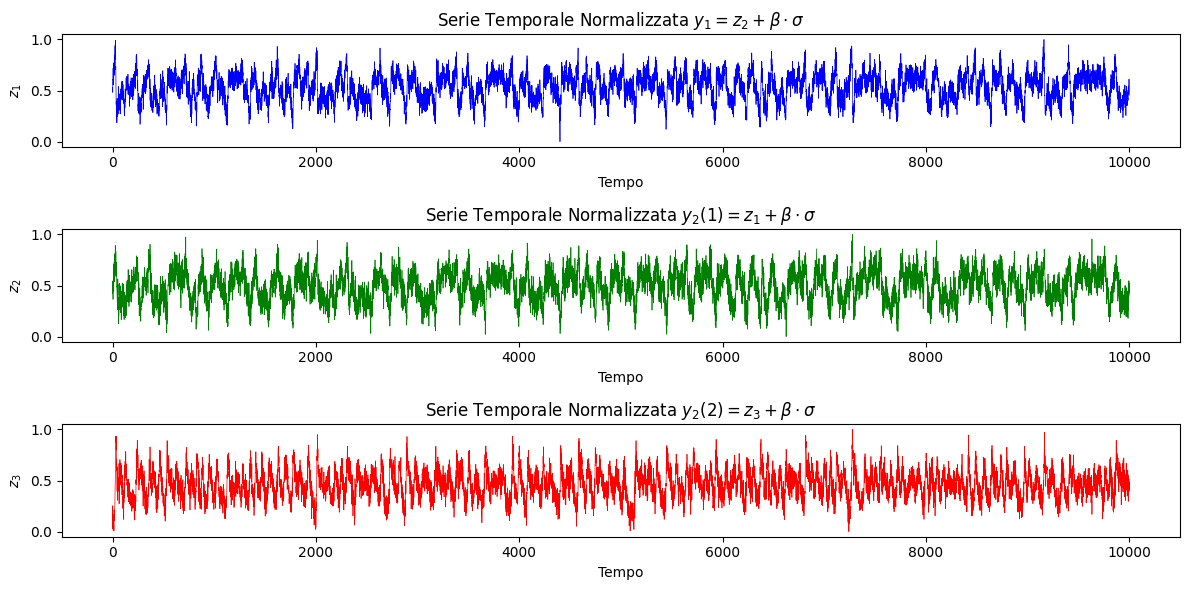

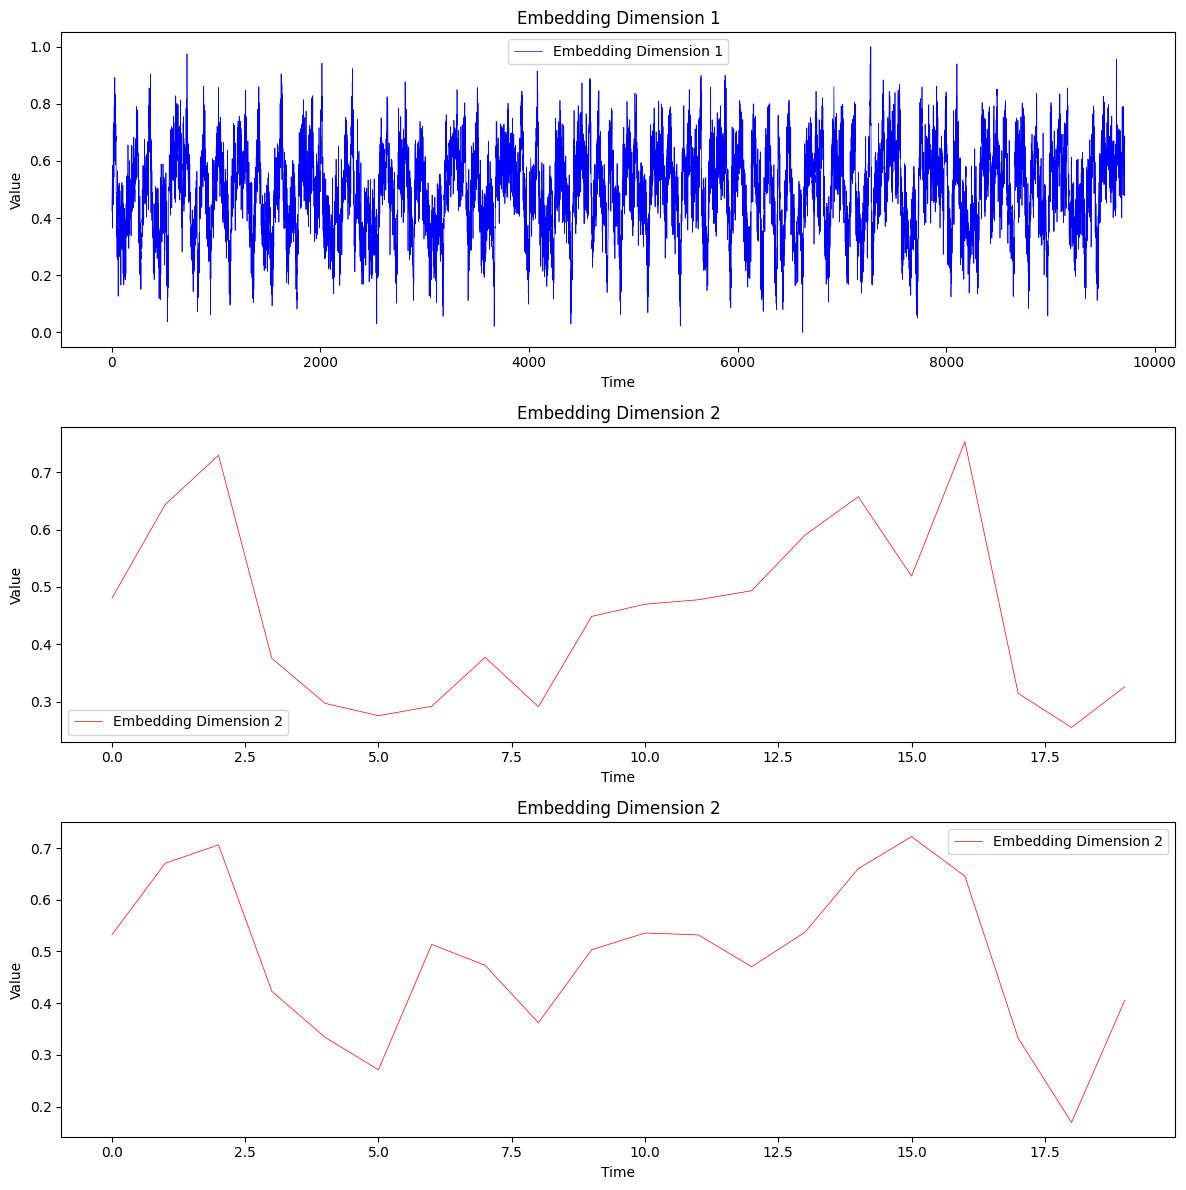

In [31]:
# Grafico delle serie temporali
fig = plt.figure(figsize=(12, 6))
# Primo subplot
ax1 = fig.add_subplot(311)
ax1.plot(simulation.y1_norm, color='blue', lw=0.5)
ax1.set_title(r"Serie Temporale Normalizzata $y_1 = z_2 + \beta \cdot \sigma$")
ax1.set_xlabel("Tempo")
ax1.set_ylabel("$z_1$")

ax2 = fig.add_subplot(312)
ax2.plot(simulation.y2_norm[:,0], color='green', lw=0.5)
ax2.set_title(r"Serie Temporale Normalizzata $y_2(1) = z_1 + \beta \cdot \sigma$")
ax2.set_xlabel("Tempo")
ax2.set_ylabel("$z_2$")

ax3 = fig.add_subplot(313)
ax3.plot(simulation.y2_norm[:,1], color='red', lw=0.5)
ax3.set_title(r"Serie Temporale Normalizzata $y_2(2) = z_3 + \beta \cdot \sigma$")
ax3.set_xlabel("Tempo")
ax3.set_ylabel("$z_3$")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].plot(simulation.y2_embedding_1[:, 0], label="Embedding Dimension 1", color='blue', lw=0.5)
axes[0].set_title("Embedding Dimension 1")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(simulation.y2_embedding_1[1], label="Embedding Dimension 2", color='red', lw=0.5)
axes[1].set_title("Embedding Dimension 2")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Value")
axes[1].legend()


axes[2].plot(simulation.y1_embedding[1], label="Embedding Dimension 2", color='red', lw=0.5)
axes[2].set_title("Embedding Dimension 2")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Value")
axes[2].legend()

plt.tight_layout()
plt.show()


In [32]:
sim_name = simulation.generate_filename()
output_folder = "Simulation data"

file_path = os.path.join(output_folder, sim_name)
print(file_path)

simulation.save_to_file(file_path)
print("Simulation data saved to file")


Simulation data/delay15dim20_noise9,5.json


Simulation data saved to file


In [33]:
def reconstruct_signal_from_embedding(embedding, embedding_dim, delay):
    """
    Ricostruisce il segnale originale da un embedding ritardato.

    Parametri:
    - embedding: Array numpy con l'embedding (n_samples, embedding_dim).
    - embedding_dim: Dimensione dell'embedding (int).
    - delay: Ritardo tra campioni nell'embedding (int).

    Ritorna:
    - signal_reconstructed: Array numpy 1D con il segnale ricostruito.
    """
    n_samples = embedding.shape[0] + (embedding_dim - 1) * delay
    signal_reconstructed = np.zeros(n_samples)

    # Conta quante volte ogni valore contribuisce alla ricostruzione
    weight = np.zeros(n_samples)

    for i in range(embedding.shape[0]):
        for j in range(embedding_dim):
            idx = i + j * delay
            signal_reconstructed[idx] += embedding[i, j]
            weight[idx] += 1

    # Media i valori sovrapposti
    signal_reconstructed /= np.maximum(weight, 1)  # Evita la divisione per zero

    return signal_reconstructed

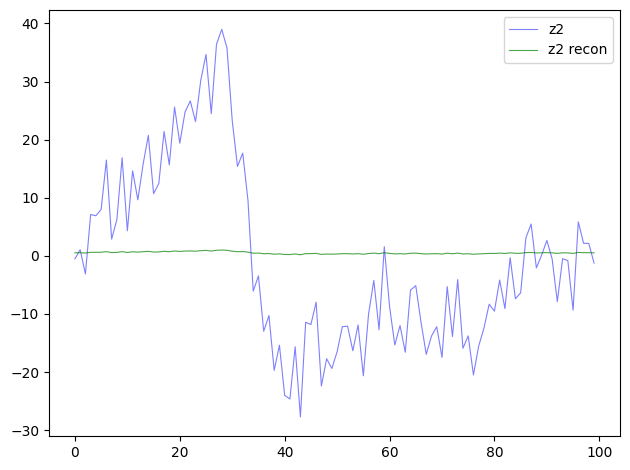

In [34]:
reconZ2 = reconstruct_signal_from_embedding(simulation.y1_embedding, embedding_dim, tau)

# Segnale y2(1)
plt.plot(simulation.y1[:100], label="z2", color='blue', alpha=0.5, lw=0.8)
plt.plot(reconZ2[:100], label="z2 recon", color='green', alpha=0.7, lw=0.8)
plt.legend()

plt.tight_layout()
plt.show()

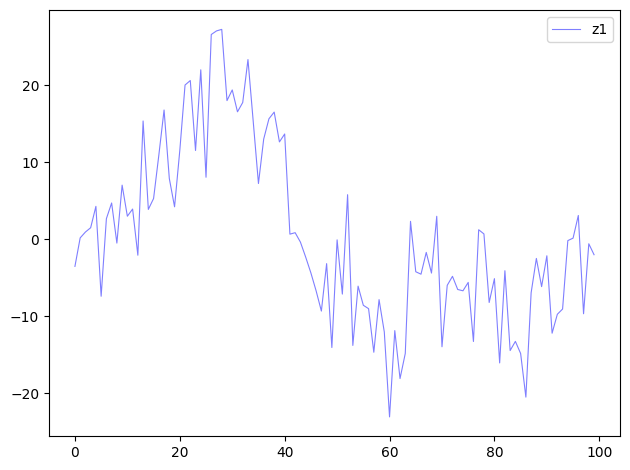

In [35]:
reconZ1 = reconstruct_signal_from_embedding(simulation.y2_embedding_1, embedding_dim, tau)

# Segnale y2(1)
plt.plot(simulation.y2[:100,0], label="z1", color='blue', alpha=0.5, lw=0.8)
#plt.plot(reconZ1[:100], label="z1 recon", color='green', alpha=0.7, lw=0.8)
plt.legend()

plt.tight_layout()
plt.show()

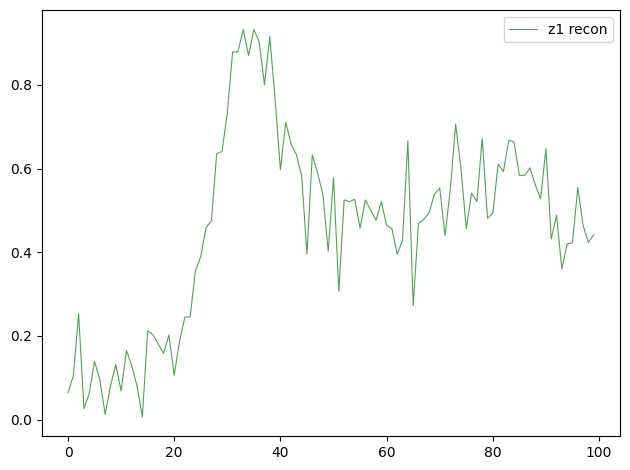

In [36]:
reconZ3 = reconstruct_signal_from_embedding(simulation.y2_embedding_2, embedding_dim, tau)

# Segnale y2(1)
#plt.plot(simulation.y2[:100,1], label="z1", color='blue', alpha=0.5, lw=0.8)
plt.plot(reconZ3[:100], label="z1 recon", color='green', alpha=0.7, lw=0.8)
plt.legend()

plt.tight_layout()
plt.show()